In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from hockey_rink import NHLRink, CircularImage, LowerInwardArcRectangle
import matplotlib.image as mpimg

import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()
conn_string = os.getenv("CONN_STRING")

In [2]:
engine = create_engine(conn_string)
query = ""
with open('shotmap query.txt', 'r') as file:
    query = file.read()
df = pd.read_sql_query(text(query), engine)
teams = pd.read_sql_query(text("SELECT * FROM teams WHERE season_id = 8"), engine)
states = pd.read_sql_query(text("SELECT * FROM states JOIN teamstates ON states.state_id = teamstates.state_id JOIN games ON states.game_id = games.game_id WHERE games.season_id = 8"), engine)


In [3]:
engine = create_engine(conn_string)
ranks_5v5 = pd.read_sql_query(text(
'''WITH opp_shots AS (
  SELECT
    goalie_team_id AS team_id,
    SUM(xg) AS xga
  FROM events
  JOIN states ON events.game_id = states.game_id AND events.event_time >= states.start_time AND events.event_time < states.end_time
  JOIN teamstates ON states.state_id = teamstates.state_id AND teamstates.team_id = events.goalie_team_id
  JOIN games ON events.game_id = games.game_id
  WHERE event_type = 'shot' AND games.season_id = 8 AND skaters = 5 AND opp_skaters = 5 AND NOT goalie_pulled AND NOT opp_goalie_pulled AND goalie_id IS NOT NULL
  GROUP BY goalie_team_id
), team_shots AS (
  SELECT 
    events.team_id,
    SUM(xg) AS xgf,
    SUM(CASE WHEN is_goal IS TRUE THEN 1 ELSE 0 END) AS gf,
    COUNT(*) as shots
  FROM events
  JOIN games ON events.game_id = games.game_id
  JOIN states ON events.game_id = states.game_id AND events.event_time >= states.start_time AND events.event_time < states.end_time
  JOIN teamstates ON states.state_id = teamstates.state_id AND teamstates.team_id = events.team_id
  WHERE event_type = 'shot' AND games.season_id = 8 AND skaters = 5 AND opp_skaters = 5 AND NOT goalie_pulled AND NOT opp_goalie_pulled AND goalie_id IS NOT NULL
  GROUP BY events.team_id
), toi AS (
  SELECT
    team_id,
    SUM(end_time - start_time) / 60 AS minutes
  FROM states
  JOIN teamstates ON states.state_id = teamstates.state_id
  JOIN games ON games.game_id = states.game_id
  WHERE season_id = 8 AND skaters = 5 AND opp_skaters = 5 AND NOT goalie_pulled AND NOT opp_goalie_pulled
  GROUP BY team_id
)
SELECT
    toi.team_id,
  ROUND((xgf - xga) / minutes * 60, 2) AS xgdiff_60,
  ROUND(xgf / minutes * 60, 2) AS xgf_60,
  ROUND(xga / minutes * 60, 2) AS xga_60,
  (gf - xgf) / shots AS dsh
FROM team_shots
JOIN opp_shots ON team_shots.team_id = opp_shots.team_id
JOIN toi ON toi.team_id = team_shots.team_id
JOIN teams ON team_shots.team_id = teams.team_id
WHERE season_id = 8
ORDER BY xgdiff_60 DESC'''), engine)
ranks_5v5['xgf_rank'] = ranks_5v5['xgf_60'].rank(ascending=False)
ranks_5v5['xga_rank'] = ranks_5v5['xga_60'].rank()
ranks_5v5['dsh_rank'] = ranks_5v5['dsh'].rank(ascending=False)
print(ranks_5v5)

   team_id  xgdiff_60  xgf_60  xga_60       dsh  xgf_rank  xga_rank  dsh_rank
0        3       0.45    2.09    1.63 -0.010623       2.0       1.0       6.0
1        4       0.37    2.19    1.82 -0.014909       1.0       3.0       7.0
2        2       0.10    2.02    1.92  0.007279       3.0       5.0       2.0
3        1       0.09    1.87    1.78  0.007231       7.0       2.0       3.0
4        6       0.04    1.93    1.89 -0.023446       4.5       4.0       8.0
5        9      -0.24    1.86    2.11  0.008354       8.0       6.0       1.0
6        8      -0.38    1.93    2.31 -0.007968       4.5       7.0       4.0
7        5      -0.42    1.91    2.33 -0.009083       6.0       8.0       5.0


In [4]:
engine = create_engine(conn_string)
ranks_goalie = pd.read_sql_query(text('''SELECT 
  MIN(first_name || ' ' || last_name) AS name,
  CAST((SUM(xg) - CAST(SUM(CAST (is_goal AS int)) AS numeric)) / COUNT(*) AS numeric) AS dSV,
  MIN(events.goalie_team_id) AS team_id,
  COUNT(*) AS shots
FROM events
JOIN biographical ON events.goalie_id = biographical.player_id
JOIN games ON events.game_id = games.game_id
JOIN seasons ON games.season_id = seasons.season_id
JOIN states ON events.game_id = states.game_id AND events.event_time >= states.start_time AND events.event_time < states.end_time
JOIN teamstates ON states.state_id = teamstates.state_id AND teamstates.team_id = events.goalie_team_id
WHERE event_type = 'shot' AND seasons.season_id = 8 AND skaters = 5 AND opp_skaters = 5
GROUP BY goalie_id
ORDER BY dsv DESC'''), engine)
ranks_goalie['starter'] = ranks_goalie.groupby('team_id')['shots'].rank(ascending=False)
ranks_goalie = ranks_goalie[ranks_goalie['starter'] == 1]
ranks_goalie['dsv_rank'] = ranks_goalie['dsv'].rank(ascending=False)
print(ranks_goalie)

                   name       dsv  team_id  shots  starter  dsv_rank
0    Ann-Renée Desbiens  0.030561        3    478      1.0       1.0
1         Aerin Frankel  0.026945        1    522      1.0       2.0
2       Gwyneth Philips  0.019982        5    638      1.0       3.0
7           Raygan Kirk  0.011003        6    491      1.0       4.0
8         Maddie Rooney  0.005177        2    346      1.0       5.0
9   Emerance Maschmeyer  0.000275        9    435      1.0       6.0
10    Corinne Schroeder -0.000118        8    391      1.0       7.0
12        Kayle Osborne -0.006406        4    532      1.0       8.0


In [5]:
engine = create_engine(conn_string)
ranks_sptm = pd.read_sql_query(text(
'''WITH opp_shots AS (
  SELECT
    goalie_team_id AS team_id,
    SUM(xg) AS xga
  FROM events
  JOIN states ON events.game_id = states.game_id AND events.event_time >= states.start_time AND events.event_time < states.end_time
  JOIN teamstates ON states.state_id = teamstates.state_id AND teamstates.team_id = events.goalie_team_id
  JOIN games ON events.game_id = games.game_id
  WHERE event_type = 'shot' AND games.season_id = 8 AND skaters < opp_skaters AND NOT goalie_pulled AND NOT opp_goalie_pulled AND goalie_id IS NOT NULL
  GROUP BY goalie_team_id
), team_shots AS (
  SELECT 
    events.team_id,
    SUM(xg) AS xgf
  FROM events
  JOIN games ON events.game_id = games.game_id
  JOIN states ON events.game_id = states.game_id AND events.event_time >= states.start_time AND events.event_time < states.end_time
  JOIN teamstates ON states.state_id = teamstates.state_id AND teamstates.team_id = events.team_id
  WHERE event_type = 'shot' AND games.season_id = 8 AND skaters > opp_skaters AND NOT goalie_pulled AND NOT opp_goalie_pulled AND goalie_id IS NOT NULL
  GROUP BY events.team_id
), toi_pp AS (
  SELECT
    team_id,
    SUM(end_time - start_time) / 60 AS minutes
  FROM states
  JOIN teamstates ON states.state_id = teamstates.state_id
  JOIN games ON games.game_id = states.game_id
  WHERE season_id = 8 AND skaters > opp_skaters AND NOT goalie_pulled AND NOT opp_goalie_pulled
  GROUP BY team_id
), toi_pk AS (
  SELECT
    team_id,
    SUM(end_time - start_time) / 60 AS minutes
  FROM states
  JOIN teamstates ON states.state_id = teamstates.state_id
  JOIN games ON games.game_id = states.game_id
  WHERE season_id = 8 AND skaters < opp_skaters AND NOT goalie_pulled AND NOT opp_goalie_pulled
  GROUP BY team_id
)
SELECT
    toi_pp.team_id,
  ROUND(xgf / toi_pp.minutes * 60, 2) AS xgf_60,
  ROUND(xga / toi_pk.minutes * 60, 2) AS xga_60
FROM team_shots
JOIN opp_shots ON team_shots.team_id = opp_shots.team_id
JOIN toi_pp ON toi_pp.team_id = team_shots.team_id
JOIN toi_pk ON toi_pk.team_id = team_shots.team_id
JOIN teams ON team_shots.team_id = teams.team_id
WHERE season_id = 8'''), engine)
ranks_sptm['xgf_rank'] = ranks_sptm['xgf_60'].rank(ascending=False)
ranks_sptm['xga_rank'] = ranks_sptm['xga_60'].rank()
print(ranks_sptm)

   team_id  xgf_60  xga_60  xgf_rank  xga_rank
0        8    5.74    6.60       3.0       8.0
1        9    4.44    5.55       7.0       5.0
2        1    5.70    5.11       4.0       4.0
3        5    4.27    6.20       8.0       7.0
4        4    5.86    4.79       2.0       2.0
5        2    6.80    4.97       1.0       3.0
6        6    4.96    5.60       6.0       6.0
7        3    5.49    4.61       5.0       1.0


In [6]:
def get_ordinal(n):
    # Handle 11, 12, 13 separately because they always use 'th'
    if 11 <= (n % 100) <= 13:
        suffix = 'th'
    else:
        # Map 1 -> st, 2 -> nd, 3 -> rd, others -> th
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
    return f"{n}{suffix}"

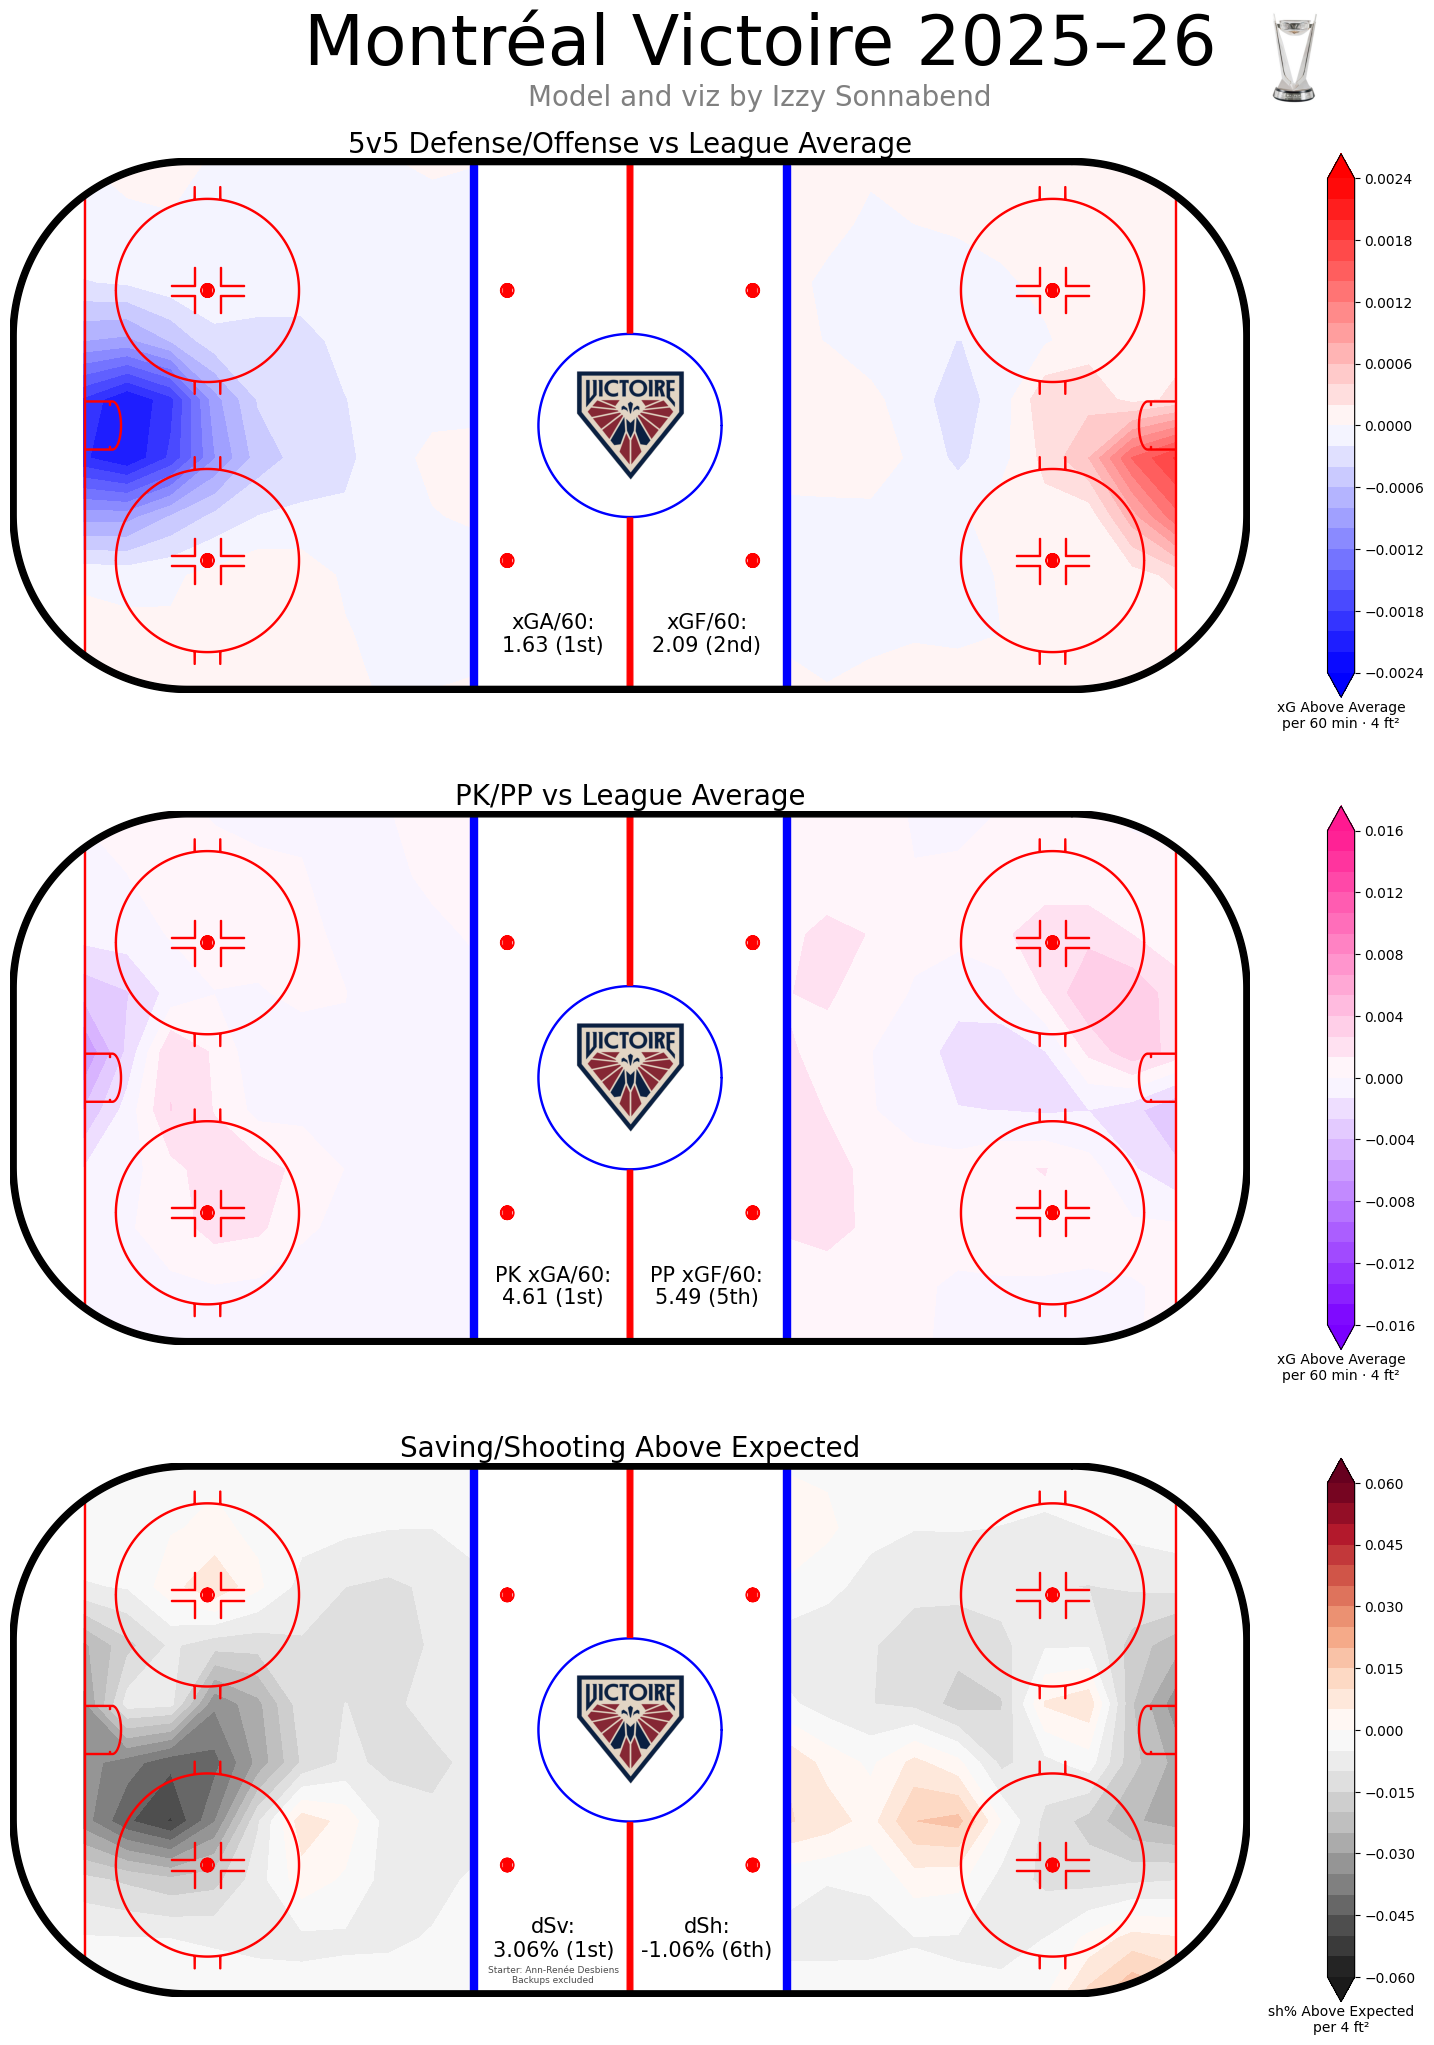

In [26]:
team = 3
team_name = teams[teams['team_id'] == team]['city'].values[0] + " " + teams[teams['team_id'] == team]['nickname'].values[0] 


rink = NHLRink(
    center_logo={
        "feature_class": CircularImage,
        "image_path": teams[teams['team_id'] == team]['team_logo_url'].values[0],
        "length": 20, "width": 18,
        "x": 0, "y": 0,
        "radius": 14,
        "zorder": 11,
    },
    red_line={
        "feature_class": LowerInwardArcRectangle,
        "radius": 15 + 1/12,
        "is_reflected_y": [False, True],
    },
    center_dot={"visible": False},
    ref_circle={"visible": False},
    net={"visible": False},
    crease={"fill": None},
    trapezoid={"visible": False}
)

fig, ax = plt.subplots(3, 1, figsize=(20, 24))
rink_5v5 = rink.draw(ax=ax[0])
rink_special_teams = rink.draw(ax=ax[1])
rink_goaltending = rink.draw(ax=ax[2])

plt.suptitle(f"{team_name} 2025–26", fontsize=50, ha='center', va='center', y=0.925)
plt.figtext(0.5, 0.9, "Model and viz by Izzy Sonnabend", ha="center", fontsize=20, color='gray')
if team == 3:
    img = mpimg.imread('walter.png')
    walter_ax = fig.add_axes([0.74, 0.9, 0.04, 0.04], anchor='NE', zorder=13)
    walter_ax.imshow(img)
    walter_ax.axis('off')

text_rely = -34
text_relx = 12.5

# 5v5
plt.sca(ax[0])

league_5v5 = df[(df['skaters'] == 5) & (df['opp_skaters'] == 5)]
team_5v5_off = league_5v5[league_5v5['shooter_team_id'] == team]
team_5v5_def = league_5v5[league_5v5['goalie_team_id'] == team]

team_toi_5v5 = states[(states['team_id'] == team) & (states['skaters'] == 5) & (states['opp_skaters'] == 5) & (states['goalie_pulled'] == False) & (states['opp_goalie_pulled'] == False)]
team_toi_5v5 = np.sum(team_toi_5v5['end_time'] - team_toi_5v5['start_time']) / 60

league_toi_5v5 = states[(states['skaters'] == 5) & (states['opp_skaters'] == 5) & (states['goalie_pulled'] == False) & (states['opp_goalie_pulled'] == False)]
league_toi_5v5 = (np.sum(league_toi_5v5['end_time'] - league_toi_5v5['start_time'])) / 60

# 5v5 offense
xbins_off = np.linspace(25, 91, 33)
ybins_off = np.linspace(-43.5, 44.5, 44)

xg_team, _, _ = np.histogram2d(team_5v5_off['x'], team_5v5_off['y'], bins=[xbins_off, ybins_off], weights=team_5v5_off['xg'])
xg_team = np.ma.masked_invalid(xg_team)
xg_team /= (team_toi_5v5 / 60)

xg_league, _, _ = np.histogram2d(league_5v5['x'], league_5v5['y'], bins=[xbins_off, ybins_off], weights=league_5v5['xg'])
xg_league = np.ma.masked_invalid(xg_league)
xg_league /= (league_toi_5v5 / 60)

xg_diff_off = xg_team - xg_league

X_off, Y_off = np.meshgrid(xbins_off[:-1], ybins_off[:-1])
xg_diff_off = gaussian_filter(xg_diff_off, sigma=3).T

# 5v5 defense
xbins_def = np.linspace(-89, -23, 33)
ybins_def = np.linspace(-43.5, 44.5, 44)

xg_team, _, _ = np.histogram2d(-1 * team_5v5_def['x'], -1 * team_5v5_def['y'], bins=[xbins_def, ybins_def], weights=team_5v5_def['xg'])
xg_team = np.ma.masked_invalid(xg_team)
xg_team /= (team_toi_5v5 / 60)

xg_league, _, _ = np.histogram2d(-1 * league_5v5['x'], -1 * league_5v5['y'], bins=[xbins_def, ybins_def], weights=league_5v5['xg'])
xg_league = np.ma.masked_invalid(xg_league)
xg_league /= (league_toi_5v5 / 60)

xg_diff_def = xg_team - xg_league

X_def, Y_def = np.meshgrid(xbins_def[:-1], ybins_def[:-1])
xg_diff_def = gaussian_filter(xg_diff_def, sigma=3).T

# Draw 5v5

max_val_5v5 = .0024

contour_left = rink.contourf(X_def.flatten(), Y_def.flatten(), xg_diff_def.flatten(), levels=np.linspace(-max_val_5v5, max_val_5v5, 25), ax=ax[0], cmap='bwr', extend='both')
contour_right = rink.contourf(X_off.flatten(), Y_off.flatten(), xg_diff_off.flatten(), levels=np.linspace(-max_val_5v5, max_val_5v5, 25), ax=ax[0], cmap='bwr', extend='both')

ax[0].set_title(f"5v5 Defense/Offense vs League Average", fontsize=20, ha='center', va='center', zorder=12)
cbar_5v5 = plt.colorbar(contour_right, ax=ax[0], orientation="vertical")
cbar_5v5.ax.set_xlabel('xG Above Average\nper 60 min \u22c5 4 ft²', labelpad=20)

ranks_5v5_filtered = ranks_5v5[ranks_5v5['team_id'] == team]
rank_xgf = int(ranks_5v5_filtered['xgf_rank'].item())
rank_xga = int(ranks_5v5_filtered['xga_rank'].item())
ax[0].text(text_relx, text_rely, f"xGF/60:\n{team_5v5_off['xg'].sum() / team_toi_5v5 * 60:.2f} ({get_ordinal(rank_xgf)})", ha='center', va='center', fontsize=15)
ax[0].text(-text_relx, text_rely, f"xGA/60:\n{team_5v5_def['xg'].sum() / team_toi_5v5 * 60:.2f} ({get_ordinal(rank_xga)})", ha='center', va='center', fontsize=15)


# Special teams
plt.sca(ax[1])

league_pp = df[(df['skaters'] > df['opp_skaters'])]
team_pp = league_pp[league_pp['shooter_team_id'] == team]
league_pk = df[(df['skaters'] > df['opp_skaters'])]
team_pk = league_pk[league_pk['goalie_team_id'] == team]

team_toi_pp = states[(states['team_id'] == team) & (states['skaters'] > states['opp_skaters']) & (states['goalie_pulled'] == False) & (states['opp_goalie_pulled'] == False)]
team_toi_pp = np.sum(team_toi_pp['end_time'] - team_toi_pp['start_time']) / 60
league_toi_pp = states[(states['skaters'] > states['opp_skaters'])]
league_toi_pp = (np.sum(league_toi_pp['end_time'] - league_toi_pp['start_time'])) / 60

team_toi_pk = states[(states['team_id'] == team) & (states['skaters'] < states['opp_skaters']) & (states['goalie_pulled'] == False) & (states['opp_goalie_pulled'] == False)]
team_toi_pk = np.sum(team_toi_pk['end_time'] - team_toi_pk['start_time']) / 60
league_toi_pk = states[(states['skaters'] < states['opp_skaters'])]
league_toi_pk = (np.sum(league_toi_pk['end_time'] - league_toi_pk['start_time'])) / 60

# Power play
xbins_pp = np.linspace(25, 91, 33)
ybins_pp = np.linspace(-43.5, 44.5, 44)

xg_team, _, _ = np.histogram2d(team_pp['x'], team_pp['y'], bins=[xbins_pp, ybins_pp], weights=team_pp['xg'])
xg_team = np.ma.masked_invalid(xg_team)
xg_team /= (team_toi_pp / 60)

xg_league, _, _ = np.histogram2d(league_pp['x'], league_pp['y'], bins=[xbins_pp, ybins_pp], weights=league_pp['xg'])
xg_league = np.ma.masked_invalid(xg_league)
xg_league /= (league_toi_pp / 60)

xg_diff_pp = xg_team - xg_league

X_pp, Y_pp = np.meshgrid(xbins_pp[:-1], ybins_pp[:-1])
xg_diff_pp = gaussian_filter(xg_diff_pp, sigma=3).T

# Penalty kill
xbins_pk = np.linspace(-89, -23, 33)
ybins_pk = np.linspace(-43.5, 44.5, 44)

xg_team, _, _ = np.histogram2d(-1 * team_pk['x'], -1 * team_pk['y'], bins=[xbins_pk, ybins_pk], weights=team_pk['xg'])
xg_team = np.ma.masked_invalid(xg_team)
xg_team /= (team_toi_pk / 60)

xg_league, _, _ = np.histogram2d(-1 * league_pk['x'], -1 * league_pk['y'], bins=[xbins_pk, ybins_pk], weights=league_pk['xg'])
xg_league = np.ma.masked_invalid(xg_league)
xg_league /= (league_toi_pk / 60)

xg_diff_pk = xg_team - xg_league

X_pk, Y_pk = np.meshgrid(xbins_pk[:-1], ybins_pk[:-1])
xg_diff_pk = gaussian_filter(xg_diff_pk, sigma=3).T

# Draw special teams
special_teams_cmap = colors.LinearSegmentedColormap.from_list('my gradient', (
    # Edit this gradient at https://eltos.github.io/gradient/#7A00FF-FFFFFF-FF1991
    (0.000, (0.478, 0.000, 1.000)),
    (0.500, (1.000, 1.000, 1.000)),
    (1.000, (1.000, 0.098, 0.569))))

max_val_pp = .016

contour_left = rink.contourf(X_pk.flatten(), Y_pk.flatten(), xg_diff_pk.flatten(), levels=np.linspace(-max_val_pp, max_val_pp, 25), ax=ax[1], cmap=special_teams_cmap, extend='both')
contour_right = rink.contourf(X_pp.flatten(), Y_pp.flatten(), xg_diff_pp.flatten(), levels=np.linspace(-max_val_pp, max_val_pp, 25), ax=ax[1], cmap=special_teams_cmap, extend='both')

plt.title(f"PK/PP vs League Average", fontsize=20, ha='center', va='center', zorder=12)
pp_cbar = plt.colorbar(contour_right, ax=ax[1], orientation="vertical")
pp_cbar.ax.set_xlabel('xG Above Average\nper 60 min \u22c5 4 ft²', labelpad=20)

ranks_sptm_filtered = ranks_sptm[ranks_sptm['team_id'] == team]
rank_xgf = int(ranks_sptm_filtered['xgf_rank'].item())
rank_xga = int(ranks_sptm_filtered['xga_rank'].item())
ax[1].text(text_relx, text_rely, f"PP xGF/60:\n{team_pp['xg'].sum() / team_toi_pp * 60:.2f} ({get_ordinal(rank_xgf)})", ha='center', va='center', fontsize=15)
ax[1].text(-text_relx, text_rely, f"PK xGA/60:\n{team_pk['xg'].sum() / team_toi_pk * 60:.2f} ({get_ordinal(rank_xga)})", ha='center', va='center', fontsize=15)

# Finishing/goaltending
plt.sca(ax[2])

team_5v5_goaltending = team_5v5_def[team_5v5_def['goalie_id'] == team_5v5_def['goalie_id'].mode()[0]]


# Finishing
xg_expected, _, _ = np.histogram2d(team_5v5_off['x'], team_5v5_off['y'], bins=[xbins_off, ybins_off], weights=team_5v5_off['xg'])
xg_expected = np.ma.masked_invalid(xg_expected)

xg_actual, _, _ = np.histogram2d(team_5v5_off['x'], team_5v5_off['y'], bins=[xbins_off, ybins_off], weights=team_5v5_off['is_goal'])
xg_actual = np.ma.masked_invalid(xg_actual)

total_shots, _, _ = np.histogram2d(team_5v5_off['x'], team_5v5_off['y'], bins=[xbins_off, ybins_off])

xg_diff_finishing = (xg_actual - xg_expected) / total_shots

X_finishing, Y_finishing = np.meshgrid(xbins_off[:-1], ybins_off[:-1])
xg_diff_finishing = gaussian_filter(xg_diff_finishing, sigma=3).T

# Goaltending
xg_expected, _, _ = np.histogram2d(-1 * team_5v5_goaltending['x'], -1 * team_5v5_goaltending['y'], bins=[xbins_def, ybins_def], weights=team_5v5_goaltending['xg'])
xg_expected = np.ma.masked_invalid(xg_expected)

xg_actual, _, _ = np.histogram2d(-1 * team_5v5_goaltending['x'], -1 * team_5v5_goaltending['y'], bins=[xbins_def, ybins_def], weights=team_5v5_goaltending['is_goal'])
xg_actual = np.ma.masked_invalid(xg_actual)

total_shots, _, _ = np.histogram2d(team_5v5_goaltending['x'], team_5v5_goaltending['y'], bins=[xbins_def, ybins_def])

xg_diff_goaltending = (xg_actual - xg_expected) / total_shots

X_goaltending, Y_goaltending = np.meshgrid(xbins_def[:-1], ybins_def[:-1])
xg_diff_goaltending = gaussian_filter(xg_diff_goaltending, sigma=3).T

# Draw finishing/goaltending

max_val_finishing = 0.06

ranks_goalie_filtered = ranks_goalie[ranks_goalie['team_id'] == team]
rank_dsh = int(ranks_5v5_filtered['dsh_rank'].item())
rank_dsv = int(ranks_goalie_filtered['dsv_rank'].item())
starter = ranks_goalie_filtered['name'].item()
ax[2].text(text_relx, text_rely, f"dSh:\n{(team_5v5_off['is_goal'].sum() - team_5v5_off['xg'].sum()) / len(team_5v5_off['xg']) * 100:.2f}% ({get_ordinal(rank_dsh)})", ha='center', va='center', fontsize=15)
ax[2].text(-text_relx, text_rely, f"dSv:\n{(team_5v5_goaltending['xg'].sum() - team_5v5_goaltending['is_goal'].sum()) / len(team_5v5_goaltending['xg'])*100:.2f}% ({get_ordinal(rank_dsv)})", ha='center', va='center', fontsize=15)
ax[2].text(-text_relx, text_rely - 6, f"Starter: {starter}\nBackups excluded", ha='center', va='center', fontsize=6.5, alpha=0.7)



contour_left = rink.contourf(X_goaltending.flatten(), Y_goaltending.flatten(), xg_diff_goaltending.flatten(), levels=np.linspace(-max_val_finishing, max_val_finishing, 25), ax=ax[2], cmap='RdGy_r', extend='both')
contour_right = rink.contourf(X_finishing.flatten(), Y_finishing.flatten(), xg_diff_finishing.flatten(), levels=np.linspace(-max_val_finishing, max_val_finishing, 25), ax=ax[2], cmap='RdGy_r', extend='both')

plt.title(f"Saving/Shooting Above Expected", fontsize=20, ha='center', va='center', zorder=12)
finish_cbar = plt.colorbar(contour_right, ax=ax[2], orientation="vertical")
finish_cbar.ax.set_xlabel('sh% Above Expected\nper 4 ft²', labelpad=20)

plt.savefig(f"output/{team_name}_shotmap.png", format='png', bbox_inches='tight')
